# Compare all experiments
Reads every run saved in the team Drive and compares them. **No GPU needed**, and it only reads files,
so you can run it any time, as more runs come in.

Each run is one order + one replay method + one seed. The question: do the replay methods keep more of
the earlier stages than no replay, and does MFR keep more than random replay at the same cost?

In [1]:
import os, sys

if os.path.exists("/content"):   # on Colab: get the latest code from GitHub
    if not os.path.exists("/content/mfr-dpo"):
        !git clone -q https://github.com/prabudhd2003/mfr-dpo.git /content/mfr-dpo
    !git -C /content/mfr-dpo pull -q
    REPO = "/content/mfr-dpo"
else:
    REPO = ".."

sys.path.insert(0, f"{REPO}/src")
import importlib, mfr_analysis
importlib.reload(mfr_analysis)
from mfr_analysis import METHOD_COLORS, METHOD_ORDER

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount("/content/drive")

# Your path to the team folder in Drive
DRIVE_DIR = "/content/drive/MyDrive/CSCI544/mfr-dpo"

runs = mfr_analysis.load_runs(DRIVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2 runs found:
  o2_mfr_s0                stages finished: 3/3
  pilot_safe_first         stages finished: 3/3


## 1. What survived, and what was learned
One row per finished run. **change** is how many accuracy points an earlier stage lost by the end
(closer to 0 is better). The last column is the stage that was trained last (higher is better):
a method that protects the past by refusing to learn the present is not a good method.

In [3]:
summary = mfr_analysis.summary_table(runs)
summary

,run_name,order_id,method,seed,mean change (points),worst change (points),mean margin kept (%),new stage (quality) (%)
0,o2_mfr_s0,2,mfr,0,-6.0,-11.0,100.7,74.0
1,pilot_safe_first,2,none,0,-9.0,-18.0,82.6,77.0


In [4]:
# the same, per earlier dataset
retention = mfr_analysis.retention_table(runs)
retention

,run_name,order_id,method,seed,dataset,learned_at,right_after,at_end,change,margin_kept
0,o2_mfr_s0,2,mfr,0,safe,1,87.5,76.5,-11.0,52.8
1,o2_mfr_s0,2,mfr,0,helpful,2,62.0,61.0,-1.0,148.6
2,pilot_safe_first,2,none,0,safe,1,87.5,69.5,-18.0,31.2
3,pilot_safe_first,2,none,0,helpful,2,61.5,61.5,0.0,134.0


## 2. The main picture
How much each earlier dataset lost, by method. Bars closer to zero mean less forgetting.

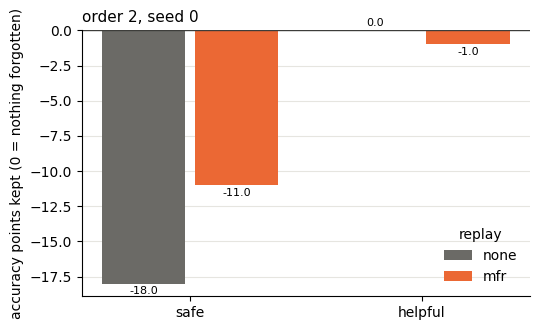

In [5]:
if len(retention):
    blocks = retention.groupby(["order_id", "seed"], observed=True)
    fig, axes = plt.subplots(1, len(blocks), figsize=(5.5 * len(blocks), 3.4), squeeze=False, sharey=True)
    for ax, ((order_id, seed), part) in zip(axes[0], blocks):
        datasets = list(dict.fromkeys(part["dataset"]))
        methods = [m for m in METHOD_ORDER if m in set(part["method"])]
        width = 0.8 / max(1, len(methods))
        for i, method in enumerate(methods):
            rows = part[part["method"] == method].set_index("dataset").reindex(datasets)
            positions = [x + i * width - 0.4 + width / 2 for x in range(len(datasets))]
            bars = ax.bar(positions, rows["change"].fillna(0), width=width * 0.9,
                          color=METHOD_COLORS.get(method, "#999"), label=method)
            ax.bar_label(bars, fmt="%.1f", fontsize=8, padding=2)
        ax.axhline(0, color="#3d3d3a", linewidth=1)
        ax.set_xticks(range(len(datasets)), datasets)
        ax.set_title(f"order {order_id}, seed {seed}", loc="left", fontsize=11)
        ax.grid(axis="y", color="#e6e5e0", linewidth=0.8)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    axes[0][0].set_ylabel("accuracy points kept (0 = nothing forgotten)")
    axes[0][-1].legend(frameon=False, title="replay", loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("no finished runs yet")

## 3. Stage by stage
Accuracy on each validation set after each stage. One panel per dataset, one line per method.
Pick which order and seed to look at.

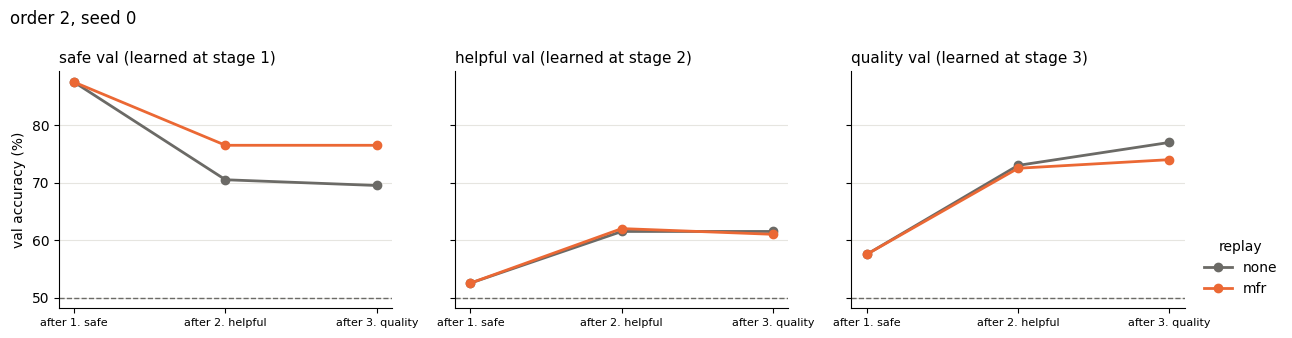

In [6]:
ORDER_ID, SEED = 2, 0

part = runs[(runs["order_id"] == ORDER_ID) & (runs["seed"] == SEED)]
order = part["order"].iloc[0] if len(part) else []
methods = [m for m in METHOD_ORDER if m in set(part["method"])]

if len(part):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
    for ax, dataset in zip(axes, order):
        for method in methods:
            line = part[(part["method"] == method) & (part["eval_set"] == dataset)].sort_values("stage")
            ax.plot(line["stage"], line["accuracy"], marker="o", markersize=6, linewidth=2,
                    color=METHOD_COLORS.get(method, "#999"), label=method)
        ax.axhline(50, color="#6b6a66", linestyle="--", linewidth=1)
        ax.set_title(f"{dataset} val (learned at stage {order.index(dataset) + 1})", loc="left", fontsize=11)
        ax.set_xticks(sorted(part["stage"].unique()), [f"after {s}. {order[s - 1]}" for s in sorted(part["stage"].unique())],
                      fontsize=8)
        ax.grid(axis="y", color="#e6e5e0", linewidth=0.8)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    axes[0].set_ylabel("val accuracy (%)")
    axes[-1].legend(frameon=False, title="replay", loc="lower left", bbox_to_anchor=(1.02, 0))
    plt.suptitle(f"order {ORDER_ID}, seed {SEED}", x=0.01, ha="left", fontsize=12)
    plt.tight_layout()
    plt.show()

## 4. MFR versus random, head to head
The comparison the project is about: same order, same seed, same budget, only the choice of replayed
pairs differs. Positive numbers mean MFR kept more.

In [7]:
pairs = []
for (order_id, seed), part in retention.groupby(["order_id", "seed"], observed=True) if len(retention) else []:
    wide = part.pivot_table(index="dataset", columns="method", values="change", observed=True)
    if {"mfr", "random"} <= set(wide.columns):
        for dataset, row in wide.iterrows():
            entry = {"order": order_id, "seed": seed, "dataset": dataset,
                     "mfr - random": round(row["mfr"] - row["random"], 2)}
            if "none" in wide.columns:
                entry["mfr - no replay"] = round(row["mfr"] - row["none"], 2)
                entry["random - no replay"] = round(row["random"] - row["none"], 2)
            pairs.append(entry)
pd.DataFrame(pairs) if pairs else "need an mfr run and a random run of the same order and seed"

'need an mfr run and a random run of the same order and seed'

## 5. Cost
Replay itself is free (the same number of steps), but MFR and lowest-margin pay for re-measuring the
buffer. That cost belongs in the paper.

In [ ]:
mfr_analysis.cost_table(runs)

In [ ]:
# what each method actually replayed
mfr_analysis.replay_summary(runs)

## 6. Is the forgetting concentrated in a few pairs?
If the worst 10% of pairs carry far more than 10% of the total loss, targeted replay has something to aim at.

In [ ]:
rows = []
for run_name, part in runs.groupby("run_name", observed=True):
    folder, order = part["folder"].iloc[0], part["order"].iloc[0]
    if part["stage"].max() < len(order):
        continue
    for dataset in order[:-1]:
        shares = mfr_analysis.concentration(folder, order, dataset)
        if shares:
            rows.append({"run": run_name, "method": str(part["method"].iloc[0]), "dataset": dataset, **shares})
pd.DataFrame(rows) if rows else "no finished runs yet"

**Reading the results**

* **change (section 1 and 2):** 0 means nothing was forgotten. The pilot with no replay lost 18 points on safe.
* A replay method works if its bars sit closer to zero **and** its last column (the new stage) stays high.
* **MFR wins** if "mfr - random" is positive across orders and seeds, while its new-stage accuracy stays
  within about 2 points of random's.
* With one seed, differences of 1 to 2 points are noise. Two seeds per method is what makes a difference real.